In [4]:
import matplotlib.pyplot as plt
import os

In [5]:
class Rectangle2D(object):
    def __init__(self, x, y, width, height, label=None, attrs={}):
        self.label = label

        self.x, self.y = x, y
        self.width, self.height = width, height

        self.attrs = attrs

    
    def split(self, axis, position):
        if axis == "horizontal":
            return (Rectangle2D(self.x, self.y, self.width, position, attrs=self.attrs), 
                    Rectangle2D(self.x, self.y + position, self.width, self.height - position, attrs=self.attrs))
        
        elif axis == "vertical":
            return (Rectangle2D(self.x, self.y, position, self.height, attrs=self.attrs),
                    Rectangle2D(self.x + position, self.y, self.width - position, self.height, attrs=self.attrs))

    
    def get_patch(self):
        return plt.Rectangle((self.x, self.y), self.width, self.height, **self.attrs)

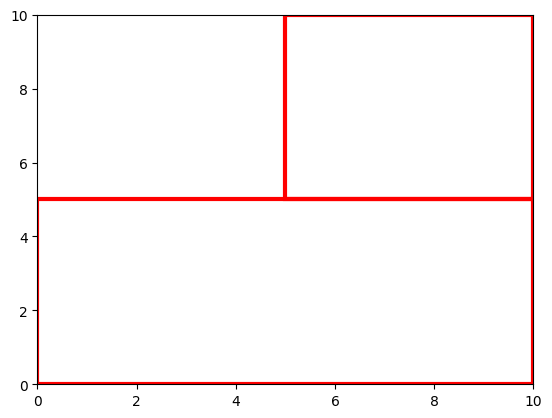

In [6]:
def draw_rectangles(rects):
    fig, ax = plt.subplots()
    
    for r in rects:
        ax.add_patch(r.get_patch())
    
    ax.set_xlim(0, max(r.x + r.width for r in rects))
    ax.set_ylim(0, max(r.y + r.height for r in rects))

    plt.show()


root = Rectangle2D(0, 0, 10, 10, attrs={"facecolor": "none", "edgecolor": "r", "linewidth": 3})
bottom, top = root.split("horizontal", 5)
top_left, top_right = top.split("vertical", 5)

draw_rectangles([bottom, top_right])

In [ ]:
class Parser(object):
    def __init__(self, dir, seed=0, nonterminals_filename="nonterminal_symbols.txt", 
                 terminals_filename="terminal_symbols.txt", rules_filename="rules.txt"):
        self.dir = dir
        self.seed = seed

        self.nonterminals_filename = nonterminals_filename
        self.terminals_filename = terminals_filename
        self.rules_filename = rules_filename

        self.init_symbols()
        self.rules = []


    def init_symbols(self):
        self.nonterminals = self.parse_symbols(self.nonterminals_filename)
        print(self.nonterminals)
        self.terminals = self.parse_symbols(self.terminals_filename)


    def init_rules(self):
        # Precompute a random number for each rule to ensure coherence during 
        # rule selection and score matching
        pass

    
    def parse_symbols(self, filename):
        with open(os.path.join(self.dir, filename), "r") as file:
            symbols = [line.rstrip("\n") for line in file]
        return symbols
    

    def parse_rules(self):
        pass


parser = Parser("./knowledge_base")

# Puis ajouter des attributs aux règles et aux symboles en créant des classes ?

['Facade', 'Wall', 'Window']
